In [124]:
import pandas as pd

In [125]:
df = pd.read_parquet("D:/Akshay/Quant/QuantForge/modules/asset_research/data/raw_data/equity/equity_daily.parquet")

In [126]:
df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Symbol
0,1980-12-12 00:00:00-05:00,0.128348,0.128906,0.128348,0.128348,0.098207,469033600,0.0,0.0,AAPL
1,1980-12-15 00:00:00-05:00,0.122210,0.122210,0.121652,0.121652,0.093083,175884800,0.0,0.0,AAPL
2,1980-12-16 00:00:00-05:00,0.113281,0.113281,0.112723,0.112723,0.086251,105728000,0.0,0.0,AAPL
3,1980-12-17 00:00:00-05:00,0.115513,0.116071,0.115513,0.115513,0.088386,86441600,0.0,0.0,AAPL
4,1980-12-18 00:00:00-05:00,0.118862,0.119420,0.118862,0.118862,0.090949,73449600,0.0,0.0,AAPL
5,1980-12-19 00:00:00-05:00,0.126116,0.126674,0.126116,0.126116,0.096499,48630400,0.0,0.0,AAPL
6,1980-12-22 00:00:00-05:00,0.132254,0.132813,0.132254,0.132254,0.101196,37363200,0.0,0.0,AAPL
7,1980-12-23 00:00:00-05:00,0.137835,0.138393,0.137835,0.137835,0.105466,46950400,0.0,0.0,AAPL
8,1980-12-24 00:00:00-05:00,0.145089,0.145647,0.145089,0.145089,0.111017,48003200,0.0,0.0,AAPL
9,1980-12-26 00:00:00-05:00,0.158482,0.159040,0.158482,0.158482,0.121264,55574400,0.0,0.0,AAPL


In [127]:
df.shape

(70280, 10)

################ Different ways to count

In [128]:
df["Symbol"].nunique()

10

In [129]:
df["Symbol"].value_counts()

Symbol
JPM      11669
AAPL     11481
MSFT     10155
AMZN      7329
NVDA      6904
GOOGL     5503
MA        5058
V         4602
TSLA      4028
META      3551
Name: count, dtype: int64

In [130]:
df["Symbol"].value_counts().reset_index()

,Symbol,count
0,JPM,11669
1,AAPL,11481
2,MSFT,10155
3,AMZN,7329
4,NVDA,6904
5,GOOGL,5503
6,MA,5058
7,V,4602
8,TSLA,4028
9,META,3551


In [131]:
df["Symbol"].value_counts().sort_values(ascending=False)

Symbol
JPM      11669
AAPL     11481
MSFT     10155
AMZN      7329
NVDA      6904
GOOGL     5503
MA        5058
V         4602
TSLA      4028
META      3551
Name: count, dtype: int64

In [132]:
df.groupby("Symbol").agg({"Close": "mean", "Volume": "sum"}).reset_index().sort_values(by="Volume", ascending=False)

,Symbol,Close,Volume
7,NVDA,16.900071,3997183617300
0,AAPL,31.585888,3523394509900
1,AMZN,49.203957,966912949300
2,GOOGL,61.951492,605914954056
6,MSFT,76.625742,561675400000
8,TSLA,108.737878,384890415300
3,JPM,55.370176,138312085700
5,META,235.275536,99129211100
9,V,130.603069,63858017000
4,MA,185.836886,51311181800


In [133]:
df.groupby("Symbol")["Date"].agg(["min", "max"]).reset_index().sort_values(by="min", ascending=True)

,Symbol,min,max
3,JPM,1980-03-17 00:00:00-05:00,2026-07-06 00:00:00-04:00
0,AAPL,1980-12-12 00:00:00-05:00,2026-07-06 00:00:00-04:00
6,MSFT,1986-03-13 00:00:00-05:00,2026-07-06 00:00:00-04:00
1,AMZN,1997-05-15 00:00:00-04:00,2026-07-06 00:00:00-04:00
7,NVDA,1999-01-22 00:00:00-05:00,2026-07-06 00:00:00-04:00
2,GOOGL,2004-08-19 00:00:00-04:00,2026-07-06 00:00:00-04:00
4,MA,2006-05-25 00:00:00-04:00,2026-07-06 00:00:00-04:00
9,V,2008-03-19 00:00:00-04:00,2026-07-06 00:00:00-04:00
8,TSLA,2010-06-29 00:00:00-04:00,2026-07-06 00:00:00-04:00
5,META,2012-05-18 00:00:00-04:00,2026-07-06 00:00:00-04:00


## Data Cleaning and Validation Checklist

### Step 1: Load the data
- Read the Parquet file into a pandas DataFrame.
- Confirm the file path is correct and the data is loaded successfully.

In [134]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Symbol
0,1980-12-12 00:00:00-05:00,0.128348,0.128906,0.128348,0.128348,0.098207,469033600,0.0,0.0,AAPL
1,1980-12-15 00:00:00-05:00,0.122210,0.122210,0.121652,0.121652,0.093083,175884800,0.0,0.0,AAPL
2,1980-12-16 00:00:00-05:00,0.113281,0.113281,0.112723,0.112723,0.086251,105728000,0.0,0.0,AAPL
3,1980-12-17 00:00:00-05:00,0.115513,0.116071,0.115513,0.115513,0.088386,86441600,0.0,0.0,AAPL
4,1980-12-18 00:00:00-05:00,0.118862,0.119420,0.118862,0.118862,0.090949,73449600,0.0,0.0,AAPL


## Step 2: Inspect the dataset structure
- Check the number of rows and columns.
- View the column names.
- Review the data types of each column.

In [135]:
df.shape

(70280, 10)

In [136]:
df["Symbol"].value_counts().reset_index()

,Symbol,count
0,JPM,11669
1,AAPL,11481
2,MSFT,10155
3,AMZN,7329
4,NVDA,6904
5,GOOGL,5503
6,MA,5058
7,V,4602
8,TSLA,4028
9,META,3551


In [137]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Dividends', 'Stock Splits', 'Symbol'],
      dtype='object')

In [138]:
df.dtypes

Date            datetime64[ns, America/New_York]
Open                                     float64
High                                     float64
Low                                      float64
Close                                    float64
Adj Close                                float64
Volume                                     int64
Dividends                                float64
Stock Splits                             float64
Symbol                                    object
dtype: object

### Step 3: Validate the date column
- Ensure the date column is in datetime format.
- Sort the data by symbol and date.
- Check that dates are in a logical order.

In [139]:
# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [140]:
# check if  it replaces it with NaT (missing date, note-a-date).
df[df["Date"]==pd.NaT] 
#or 
df[df["Date"].isna()]

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Symbol


In [141]:
df = df.sort_values(by=["Symbol", "Date"]).reset_index(drop=True)
# Check the result
print(df["Date"].head())
print(df["Date"].dtype)

# Check whether any invalid dates were introduced
print("Missing dates:", df["Date"].isna().sum())

0   1980-12-12 00:00:00-05:00
1   1980-12-15 00:00:00-05:00
2   1980-12-16 00:00:00-05:00
3   1980-12-17 00:00:00-05:00
4   1980-12-18 00:00:00-05:00
Name: Date, dtype: datetime64[ns, America/New_York]
datetime64[ns, America/New_York]
Missing dates: 0


In [142]:
#show date range per symbol
df.groupby("Symbol")["Date"].agg(["min", "max"]).reset_index()

,Symbol,min,max
0,AAPL,1980-12-12 00:00:00-05:00,2026-07-06 00:00:00-04:00
1,AMZN,1997-05-15 00:00:00-04:00,2026-07-06 00:00:00-04:00
2,GOOGL,2004-08-19 00:00:00-04:00,2026-07-06 00:00:00-04:00
3,JPM,1980-03-17 00:00:00-05:00,2026-07-06 00:00:00-04:00
4,MA,2006-05-25 00:00:00-04:00,2026-07-06 00:00:00-04:00
5,META,2012-05-18 00:00:00-04:00,2026-07-06 00:00:00-04:00
6,MSFT,1986-03-13 00:00:00-05:00,2026-07-06 00:00:00-04:00
7,NVDA,1999-01-22 00:00:00-05:00,2026-07-06 00:00:00-04:00
8,TSLA,2010-06-29 00:00:00-04:00,2026-07-06 00:00:00-04:00
9,V,2008-03-19 00:00:00-04:00,2026-07-06 00:00:00-04:00


### Step 4: Validate identifiers
- Confirm that the Symbol column exists.
- Check for missing, blank, or inconsistent symbol values.


In [ ]:
# Check whether Symbol column exists
print("Symbol in columns:", "Symbol" in df.columns)

# Check missing values
print("Missing symbols:", df["Symbol"].isna().sum())

# Check blank / empty strings
blank_symbols = df["Symbol"].astype(str).str.strip() == ""
print("Blank symbols:", blank_symbols.sum())

# Show the unique symbols
print(df["Symbol"].dropna().unique()[:20])

# show rows with missing or blank symbols
df[df["Symbol"].isna() | df["Symbol"].astype(str).str.strip().eq("")]

### Step 5: Check for duplicates
- Identify duplicate rows.
- Check for duplicates based on Symbol + Date.

In [145]:
# cleaner symbol list, you can normalize them like this:
df["Symbol"] = df["Symbol"].astype(str).str.strip()

In [ ]:
dup = df.duplicated(subset=["Symbol", "Date"], keep=False)
print("Duplicate rows based on Symbol and Date:", dup.sum())

### Step 6: Check missing values
- Review missing values in important columns such as Date, Open, High, Low, Close, and Volume.
- Decide whether to drop or fill missing values based on the business logic.

In [147]:
df = df.drop_duplicates(subset=["Symbol", "Date"], keep="first")

In [ ]:
print("Missing values in Date column", df["Date"].isna().sum())
print("Missing values in Symbol column", df["Symbol"].isna().sum())
print("Blank symbols:", (df["Symbol"].astype(str).str.strip() == "").sum())
print("Mising values in Open column", df["Open"].isna().sum())
print("Mising values in High column", df["High"].isna().sum())
print("Mising values in Low column", df["Low"].isna().sum())
print("Mising values in Close column", df["Close"].isna().sum())
print("Mising values in Volume column", df["Volume"].isna().sum())
print("Missing values in Adj Close column", df["Adj Close"].isna().sum())

### Step 7: Validate numeric fields
- Ensure price columns are numeric.
- Ensure volume is non-negative.
- Check for unrealistic values such as negative prices or zero/negative volume where it should not occur.

In [149]:
missing_summary = df[["Date", "Symbol", "Open", "High", "Low", "Close", "Volume", "Adj Close"]].isna().sum()
print(missing_summary)

Date         0
Symbol       0
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64


In [ ]:
df[["Open", "High", "Low", "Close", "Adj Close"]].dtypes

### Step 8: Check time-series consistency
- For each symbol, verify that dates are unique, the series is sorted, and there are no obvious gaps or irregularities unless expected.

In [151]:
# Check price columns are numeric
df[["Open", "High", "Low", "Close", "Adj Close"]].describe()

,Open,High,Low,Close,Adj Close
count,70280.000000,70280.000000,70280.000000,70280.000000,70280.000000
mean,77.100850,78.002508,76.181108,77.113794,73.065728
std,116.059322,117.374219,114.694767,116.058228,115.677019
min,0.034896,0.035547,0.033333,0.034115,0.031276
25%,4.110500,4.177266,4.022891,4.103063,2.457510
50%,26.458332,26.770000,26.129999,26.459999,19.859623
75%,101.320250,102.400002,100.063248,101.231628,93.441938
max,791.150024,796.250000,780.820007,790.000000,787.419189


In [152]:
# Check for negative prices
df[["Open", "High", "Low", "Close", "Adj Close"]].lt(0).sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
dtype: int64

In [153]:
df[["Volume"]].lt(0).sum()

Volume    0
dtype: int64

In [ ]:
df.groupby("Symbol")["Date"].is_monotonic_increasing

In [154]:
df.groupby("Symbol")["Date"].nunique()

Symbol
AAPL     11481
AMZN      7329
GOOGL     5503
JPM      11669
MA        5058
META      3551
MSFT     10155
NVDA      6904
TSLA      4028
V         4602
Name: Date, dtype: int64

### Step 9: Create a cleaned dataset
- Keep the raw data unchanged.
- Create a cleaned version for analysis.
- Apply only minimal and justified cleaning rules at this stage.

In [ ]:
clean_df = df.copy()
clean_df = clean_df[["Date", "Symbol", "Open", "High", "Low", "Close", "Adj Close", "Volume"]].copy()

# sort by symbol and date
clean_df = clean_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)
clean_df.head(10)

### Step 10: Produce a QC summary
- Report total row count, number of unique symbols, missing values count, duplicate count, and date range per symbol.

In [157]:
clean_df.to_parquet("../modules/asset_research/data/clean_data/cleaned_equity_data.parquet", index=False)

In [164]:
print("Total Row count:", clean_df.shape[0])
print("Total unique symbols:", clean_df["Symbol"].nunique())
print("Missing value count:", clean_df.isnull().sum().sum())
print("Duplicate count:", clean_df.duplicated(subset=["Symbol", "Date"]).sum())

qc_date_range = clean_df.groupby("Symbol")["Date"].agg(["min", "max"]).reset_index()
qc_date_range.columns = ["Symbol", "Min Date", "Max Date"]
print("\nDate range per symbol:")
display(qc_date_range)

Total Row count: 70280
Total unique symbols: 10
Missing value count: 0
Duplicate count: 0

Date range per symbol:


,Symbol,Min Date,Max Date
0,AAPL,1980-12-12 00:00:00-05:00,2026-07-06 00:00:00-04:00
1,AMZN,1997-05-15 00:00:00-04:00,2026-07-06 00:00:00-04:00
2,GOOGL,2004-08-19 00:00:00-04:00,2026-07-06 00:00:00-04:00
3,JPM,1980-03-17 00:00:00-05:00,2026-07-06 00:00:00-04:00
4,MA,2006-05-25 00:00:00-04:00,2026-07-06 00:00:00-04:00
5,META,2012-05-18 00:00:00-04:00,2026-07-06 00:00:00-04:00
6,MSFT,1986-03-13 00:00:00-05:00,2026-07-06 00:00:00-04:00
7,NVDA,1999-01-22 00:00:00-05:00,2026-07-06 00:00:00-04:00
8,TSLA,2010-06-29 00:00:00-04:00,2026-07-06 00:00:00-04:00
9,V,2008-03-19 00:00:00-04:00,2026-07-06 00:00:00-04:00


## Next Step 11: Exploratory Data Analysis (EDA)
- Review summary statistics for price and volume columns.
- Compare symbol-level distributions and time coverage.
- Look for outliers, spikes, or unusual moves in the cleaned dataset.
- Document any patterns that may matter for later feature engineering.

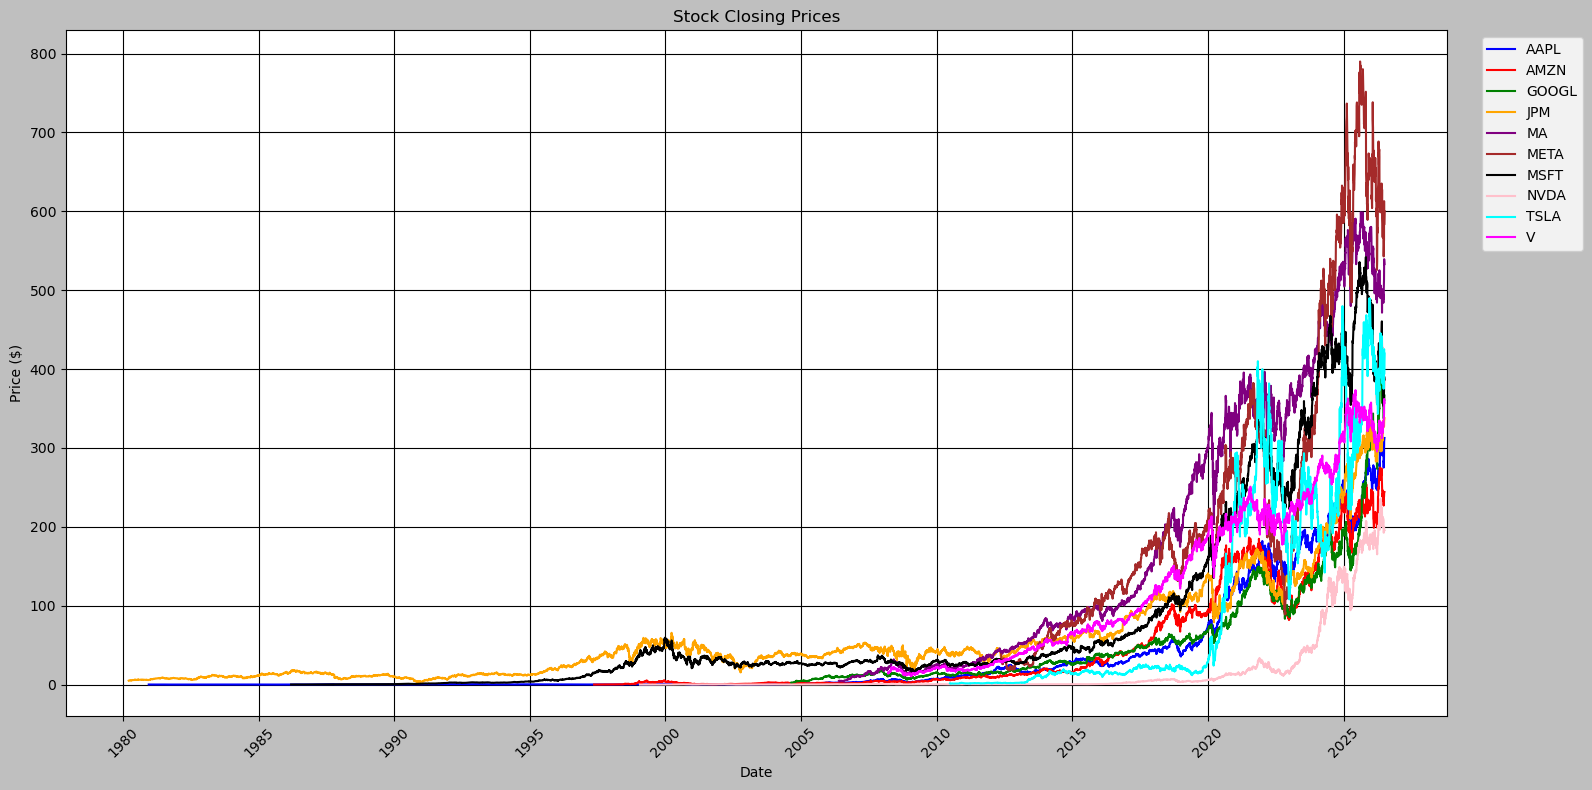

In [188]:
## EDA Sub-step: Plot Close Price for All Symbols
#### Use Date on the x-axis.
#### Use Close Price on the y-axis.
#### Plot all symbols on the same chart for cross-symbol comparison.
#### Keep the visual simple and readable.

import matplotlib.pyplot as plt

colors = [
    "blue", "red", "green", "orange", "purple",
    "brown", "black", "pink", "cyan", "magenta"
]

fig = plt.figure(figsize=(16, 8))

for i, (symbol, group) in enumerate(clean_df.groupby("Symbol")):
    color = colors[i]
    plt.plot(group["Date"], group["Close"], color=color, label=symbol)

plt.title("Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

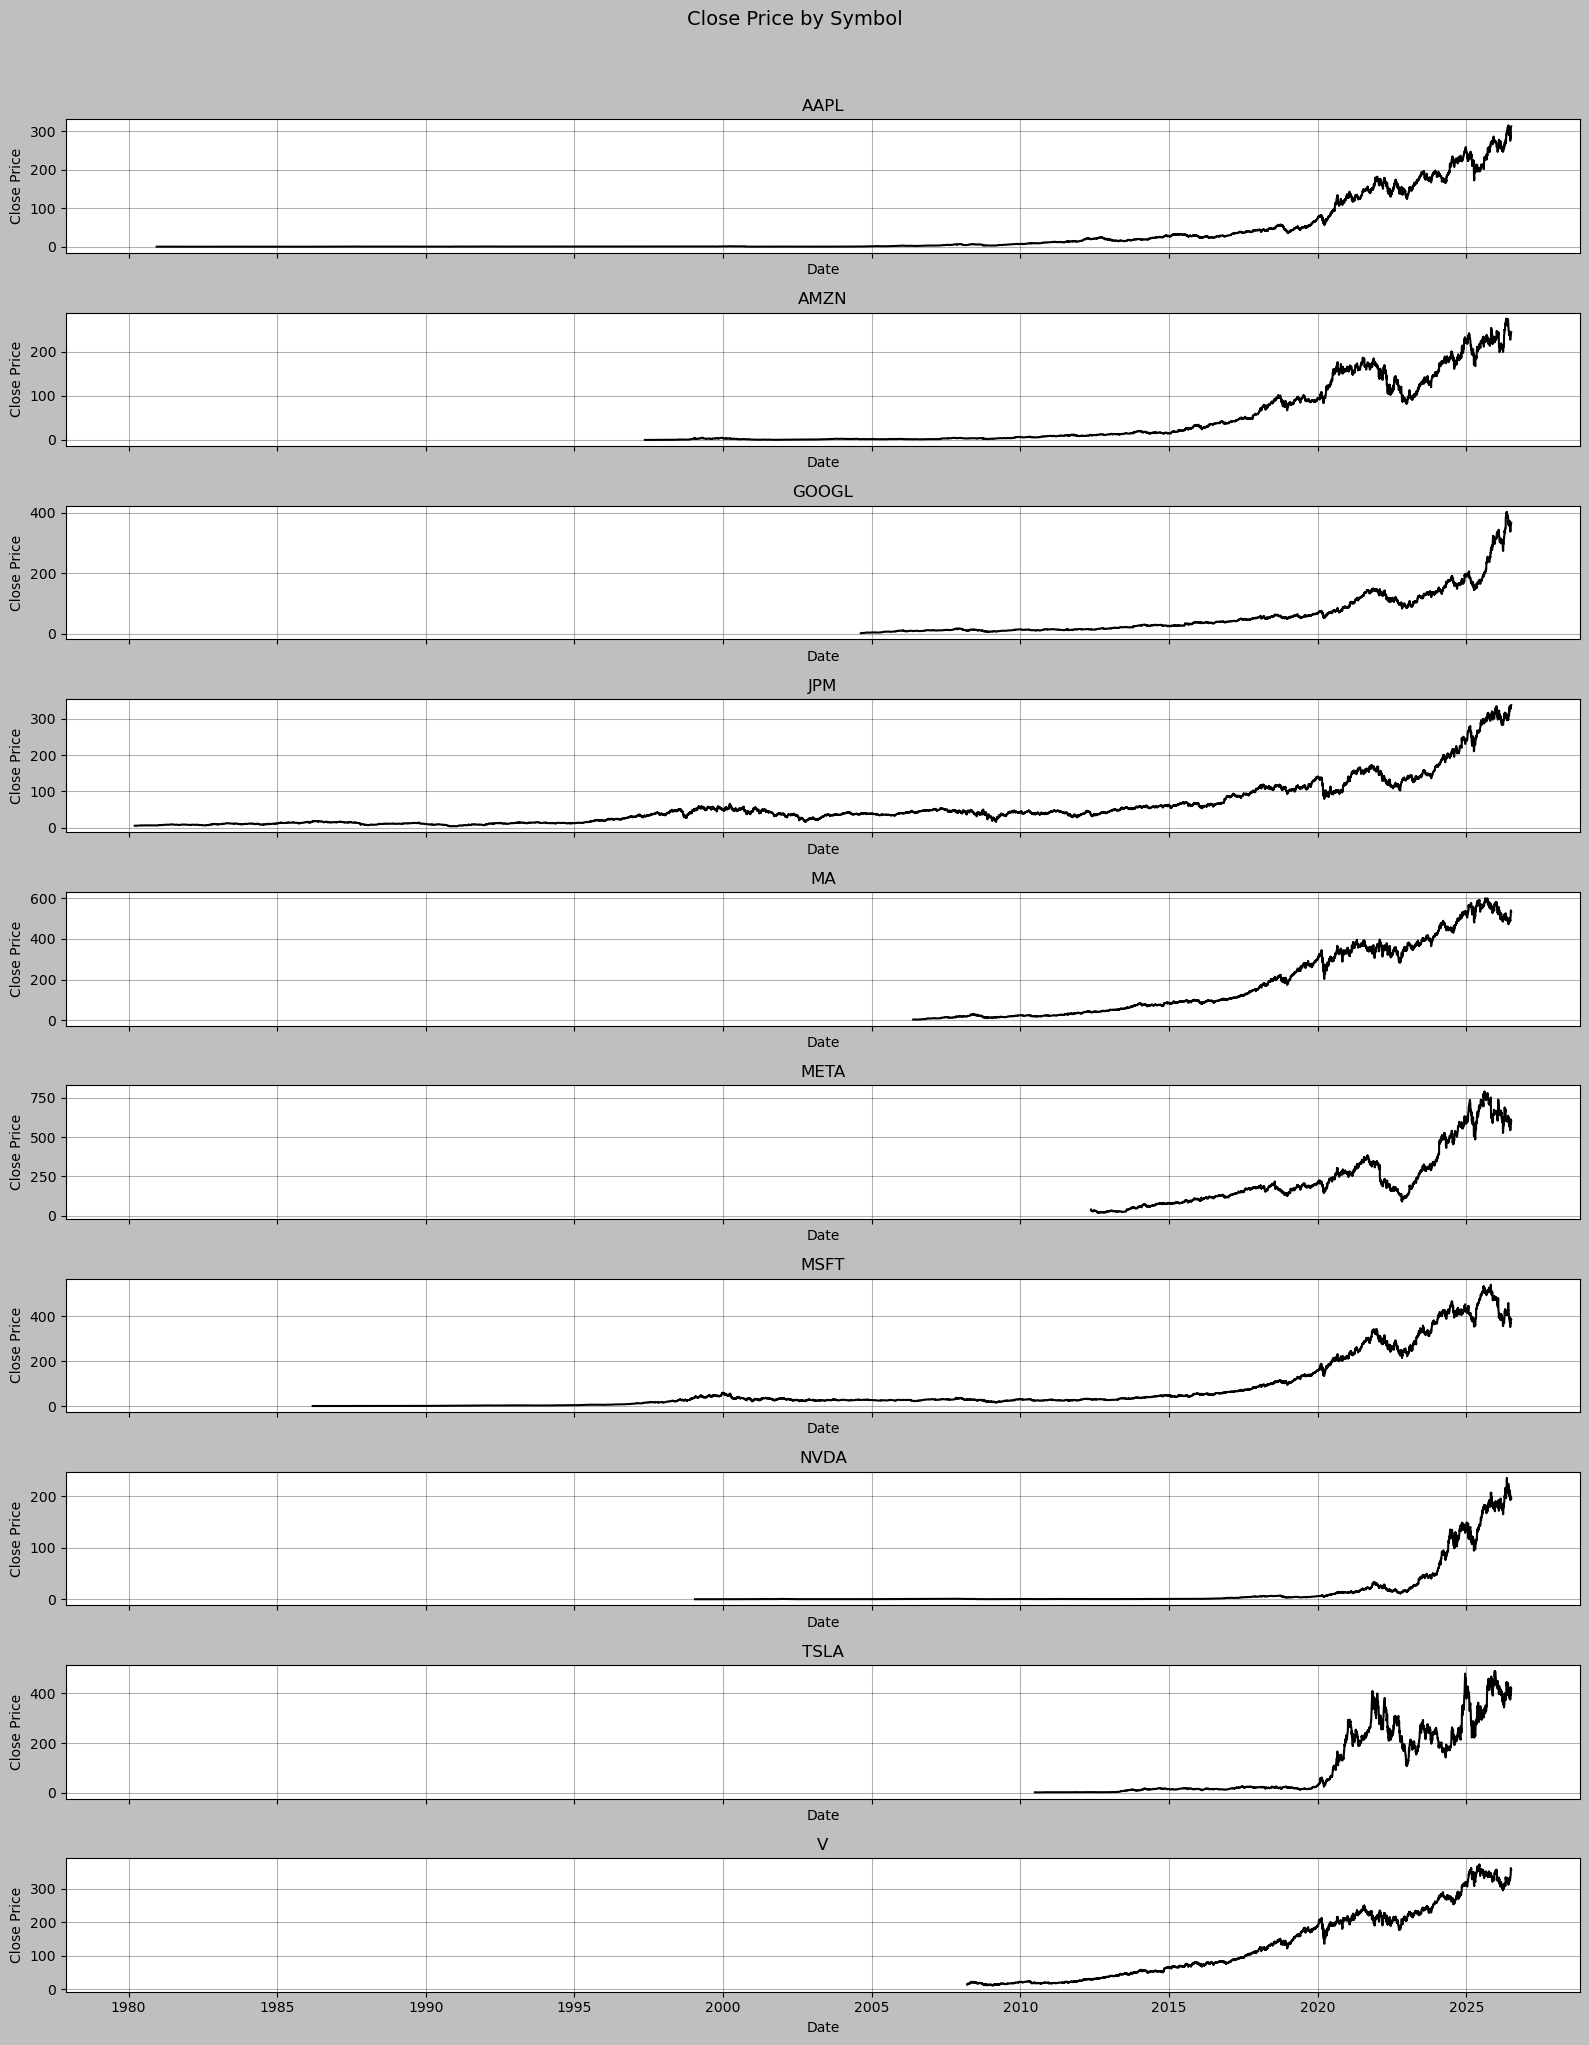

In [186]:
import matplotlib.pyplot as plt

symbols = clean_df["Symbol"].dropna().unique()
n = len(symbols)

fig, axes = plt.subplots(n, 1, figsize=(16, 2 * n), sharex=True)

for ax, symbol in zip(axes, symbols):
    s = clean_df[clean_df["Symbol"] == symbol].sort_values("Date")
    ax.plot(s["Date"], s["Close"], label=symbol)
    ax.set_title(symbol)
    ax.set_xlabel("Date")
    ax.set_ylabel("Close Price")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle("Close Price by Symbol", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [189]:
# - Review summary statistics for price and volume columns.
clean_df[["Close", "Volume"]].describe()

,Close,Volume
count,70280.000000,7.028000e+04
mean,77.113794,1.478740e+08
std,116.058228,2.657121e+08
min,0.034115,0.000000e+00
25%,4.103063,1.405522e+07
50%,26.459999,5.075560e+07
75%,101.231628,1.493408e+08
max,790.000000,9.230856e+09


In [192]:
clean_df.groupby("Symbol")[["Close", "Volume"]].describe().transpose()

Symbol                AAPL          AMZN         GOOGL           JPM  \
Close  count  1.148100e+04  7.329000e+03  5.503000e+03  1.166900e+04   
       mean   3.158589e+01  4.920396e+01  6.195149e+01  5.537018e+01   
       std    6.343100e+01  6.874232e+01  7.113428e+01  6.190008e+01   
       min    4.910700e-02  6.979200e-02  2.502753e+00  3.375000e+00   
       25%    3.058040e-01  2.186000e+00  1.349862e+01  1.295833e+01   
       50%    6.405360e-01  1.005800e+01  3.147800e+01  3.787500e+01   
       75%    2.510250e+01  8.846050e+01  8.820075e+01  5.920000e+01   
       max    3.152000e+02  2.749900e+02  4.026200e+02  3.377200e+02   
Volume count  1.148100e+04  7.329000e+03  5.503000e+03  1.166900e+04   
       mean   3.068892e+08  1.319297e+08  1.101063e+08  1.185295e+07   
       std    3.326766e+08  1.357010e+08  1.433314e+08  1.608629e+07   
       min    0.000000e+00  9.744000e+06  9.312000e+06  1.147500e+04   
       25%    1.043436e+08  5.982600e+07  2.993545e+07  1.686900e+06   
       50%    1.960000e+08  9.684400e+07  5.067328e+07  7.940900e+06   
       75%    3.870984e+08  1.516720e+08  1.294125e+08  1.421070e+07   
       max    7.421641e+09  2.086584e+09  1.643023e+09  2.172942e+08   

Symbol                  MA          META          MSFT          NVDA  \
Close  count  5.058000e+03  3.551000e+03  1.015500e+04  6.904000e+03   
       mean   1.858369e+02  2.352755e+02  7.662574e+01  1.690007e+01   
       std    1.750750e+02  1.908778e+02  1.203484e+02  4.287581e+01   
       min    4.390000e+00  1.773000e+01  9.027800e-02  3.411500e-02   
       25%    2.903950e+01  1.003750e+02  6.421875e+00  2.900987e-01   
       50%    9.754000e+01  1.761100e+02  2.791000e+01  4.895000e-01   
       75%    3.406325e+02  3.082350e+02  5.552500e+01  6.136625e+00   
       max    5.989600e+02  7.900000e+02  5.420700e+02  2.357400e+02   
Volume count  5.058000e+03  3.551000e+03  1.015500e+04  6.904000e+03   
       mean   1.014456e+07  2.791586e+07  5.531023e+07  5.789663e+08   
       std    1.590389e+07  2.487792e+07  3.792225e+07  4.291669e+08   
       min    6.411000e+05  4.726100e+06  2.304000e+06  1.968000e+07   
       25%    2.939625e+06  1.459675e+07  3.026045e+07  3.121080e+08   
       50%    4.510850e+06  2.068460e+07  4.846700e+07  4.810820e+08   
       75%    9.889000e+06  3.168470e+07  6.923280e+07  7.142670e+08   
       max    3.953430e+08  5.735764e+08  1.031789e+09  9.230856e+09   

Symbol                TSLA             V  
Close  count  4.028000e+03  4.602000e+03  
       mean   1.087379e+02  1.306031e+02  
       std    1.344126e+02  1.034756e+02  
       min    1.053333e+00  1.060500e+01  
       25%    1.307200e+01  3.443500e+01  
       50%    2.055067e+01  9.210500e+01  
       75%    2.201242e+02  2.128650e+02  
       max    4.898800e+02  3.733100e+02  
Volume count  4.028000e+03  4.602000e+03  
       mean   9.555373e+07  1.387614e+07  
       std    7.484110e+07  1.889900e+07  
       min    1.777500e+06  1.640900e+06  
       25%    5.111580e+07  6.371600e+06  
       50%    8.142780e+07  8.907400e+06  
       75%    1.196671e+08  1.461075e+07  
       max    9.140820e+08  7.084860e+08

## Next Step 12: Calculate Returns
- Build daily returns from the cleaned price series.
- Inspect return distributions and compare symbols.
- Highlight any unusual return behavior before moving into risk analysis.

## Next Step 13: Measure Risk Metrics
- Compute rolling volatility and summary volatility by symbol.
- Calculate maximum drawdown and other risk indicators.
- Compare risk across assets in a structured way.

## Next Step 14: Feature Engineering
- Create returns-based features and rolling statistics.
- Prepare a research-friendly feature table.
- Keep the engineering logic simple and explainable.

## Next Step 15: Build a Research Dataset or Ranking View
- Combine metrics and engineered features into a reusable research frame.
- Prepare the dataset for downstream analysis or ranking.
- Keep the output structured for later portfolio or factor work.